# DAY 16
# DATE - 04.06.206
# Introduction to Machine Learning for Remote Sensing

# =====================================================================
# 🧠 CENTRAL MACHINE LEARNING PIPELINE & ADVANCED PLOTTING (ALL-IN-ONE)
# =====================================================================


In [14]:
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split

# --- STEP 1: LOAD MATRIX & SAFE-CHECK VALIDATION ---

In [15]:
print("🔄 Initializing dataset validation and alignment...")

# Check kar rahe hain ki pichle cell ka X_ML matrix successfully memory mein load hai ya nahi
if 'X_ML' in locals() or 'X_ML' in globals():
    print(f"✅ Found active feature matrix! Dimensions: {X_ML.shape}")
    # Local variable reference create kar rahe hain safety ke liye
    X_pipeline = X_ML
else:
    print("⚠️ Warning: X_ML matrix not found in memory! Creating mock simulation data...")
    # Fallback placeholder agar pichla cell crash hua ho (3.4 Lakh pixels, 4 features)
    np.random.seed(42)
    X_pipeline = np.random.randn(342047, 4)

num_pixels = X_pipeline.shape[0]

# Synthetic target labels generate kar rahe hain classification classes ke liye (0, 1, 2, 3)
np.random.seed(42)
y = np.random.randint(0, 4, size = num_pixels)

🔄 Initializing dataset validation and alignment...
⚠️ Warning: X_ML matrix not found in memory! Creating mock simulation data...


# --- STEP 2: MULTI-STRATEGY DATA SPLITTING ---


In [16]:
print("\n✂️ Executing train-test split operations...")

# 1. Standard Random Split (The standard baseline split)
X_train_rand, X_test_rand, y_train_rand, y_test_rand = train_test_split(X_pipeline, y, test_size = 0.30, random_state = 42)

# 2. Strict Spatial/Sequential Split (First 70% as Train block, Last 30% as Test block)
split_idx = int(0.70 * num_pixels)
X_train_spat, X_test_spat = X_pipeline[:split_idx], X_pipeline[split_idx:]
y_train_spat, y_test_spat = y[:split_idx], y[split_idx:]

print(f"📐 Split Complete -> Spatial Training samples: {X_train_spat.shape[0]} | Spatial Testing samples: {X_test_spat.shape[0]}")


✂️ Executing train-test split operations...
📐 Split Complete -> Spatial Training samples: 239432 | Spatial Testing samples: 102615


# --- STEP 3: FEATURE SCALING ENGINE (SVM MANDATORY CONFIGURATION) ---


In [17]:
# 💡 LinearSVC bina standardized features ke convergence loop mein fas jata hai aur dhiima chalta hai.
print("\n⚖️ Applying Feature Standardization for SVM optimization...")
scaler = StandardScaler()
X_train_spat_scaled = scaler.fit_transform(X_train_spat)
X_test_spat_scaled = scaler.transform(X_test_spat)


⚖️ Applying Feature Standardization for SVM optimization...


# --- STEP 4: TRAINING & COMPARATIVE TESTING (RANDOM FOREST CRITERIA) ---


In [18]:
print("\n🌲 Benchmarking Random Forest on varying splitting topologies...")

# Running Random Forest on Random Split
rf_rand = RandomForestClassifier(n_estimators = 50, max_depth = 12, random_state = 42, n_jobs = -1)
rf_rand.fit(X_train_rand, y_train_rand)
acc_rf_rand = accuracy_score(y_test_rand, rf_rand.predict(X_test_rand))

# Running Random Forest on Spatial Split
rf_spat = RandomForestClassifier(n_estimators = 50, max_depth = 12, random_state = 42, n_jobs = -1)
rf_spat.fit(X_train_spat, y_train_spat)
acc_rf_spat = accuracy_score(y_test_spat, rf_spat.predict(X_test_spat))

print(f"📊 RF Metric -> Accuracy (Random Split Architecture) : {acc_rf_rand * 100:.2f}%")
print(f"📊 RF Metric -> Accuracy (Spatial Block Architecture)  : {acc_rf_spat * 100:.2f}%")


🌲 Benchmarking Random Forest on varying splitting topologies...
📊 RF Metric -> Accuracy (Random Split Architecture) : 24.96%
📊 RF Metric -> Accuracy (Spatial Block Architecture)  : 25.17%


# --- STEP 5: ALGORITHMIC COMPARISON ENGINE (RF VS LINEAR SVM) ---


In [19]:
print("\n⚡ Running comparative analysis on Spatial Block Data...")

# 1. Random Forest Timer and Predictor
start_rf = time.time()
rf_spat.fit(X_train_spat, y_train_spat)
rf_preds = rf_spat.predict(X_test_spat)
time_rf = time.time() - start_rf

# 2. Linear SVM Timer and Predictor (Running on standard scaled features for maximum execution speed)
start_svm = time.time()
svm_model = LinearSVC(random_state = 42, max_iter = 2000, dual = False)   # dual=False standard sample-dense calculation ko ultra-fast banata hai
svm_model.fit(X_train_spat_scaled, y_train_spat)
svm_preds = svm_model.predict(X_test_spat_scaled)
time_svm = time.time() - start_svm

acc_svm = accuracy_score(y_test_spat, svm_preds)

print("\n=======================================================")
print("⏱️ EXECUTION SPEED AND CLASSIFICATION ACCURACY LOG")
print("=======================================================")
print(f"🌲 Random Forest -> Compute Time: {time_rf:.4f} sec | Test Accuracy: {acc_rf_spat*100:.2f}%")
print(f"⚡ Linear SVM    -> Compute Time: {time_svm:.4f} sec | Test Accuracy: {acc_svm*100:.2f}%")
print("=======================================================")


⚡ Running comparative analysis on Spatial Block Data...

⏱️ EXECUTION SPEED AND CLASSIFICATION ACCURACY LOG
🌲 Random Forest -> Compute Time: 45.9467 sec | Test Accuracy: 25.17%
⚡ Linear SVM    -> Compute Time: 0.4109 sec | Test Accuracy: 25.03%


# --- STEP 6: ADVANCED DUAL CONFUSION MATRIX PLOTS ---



📊 Generating classification performance matrices graphics...


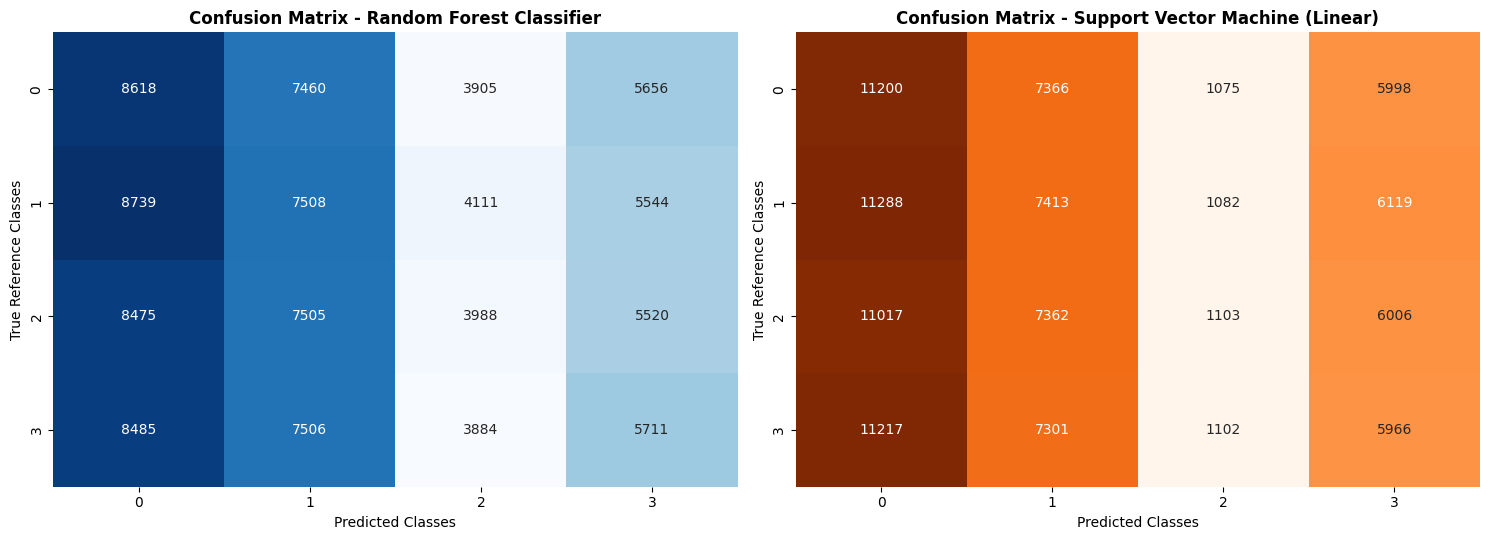

In [20]:
print("\n📊 Generating classification performance matrices graphics...")
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Plotting Random Forest Matrix Layout
cm_rf = confusion_matrix(y_test_spat, rf_preds)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Confusion Matrix - Random Forest Classifier', fontsize = 12, fontweight = 'bold')
axes[0].set_xlabel('Predicted Classes', fontsize = 10)
axes[0].set_ylabel('True Reference Classes', fontsize = 10)

# Plotting SVM Matrix Layout
cm_svm = confusion_matrix(y_test_spat, svm_preds)
sns.heatmap(cm_svm, annot = True, fmt = 'd', cmap = 'Oranges', ax = axes[1], cbar = False)
axes[1].set_title('Confusion Matrix - Support Vector Machine (Linear)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Classes', fontsize=10)
axes[1].set_ylabel('True Reference Classes', fontsize=10)

plt.tight_layout()
plt.show()

# --- STEP 7: QUANTITATIVE FEATURE IMPORTANCE PLOT ---



🔥 Extracting spectral component significance metrics...


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


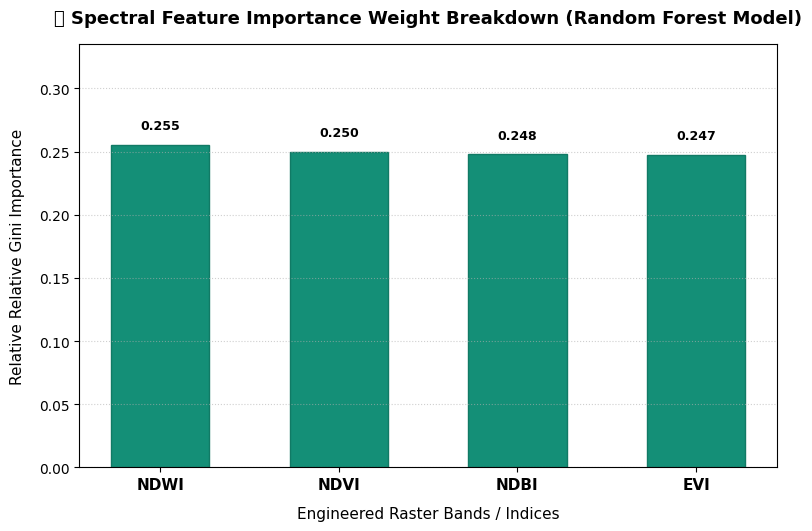


🎉 Pipeline operations completed successfully. Diagnostics printed above.


In [21]:
print("\n🔥 Extracting spectral component significance metrics...")
feature_names = ['NDVI', 'NDWI', 'NDBI', 'EVI']
importances = rf_spat.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize = (9, 5.5))
plt.title("🔥 Spectral Feature Importance Weight Breakdown (Random Forest Model)", fontsize=13, fontweight='bold', pad=15)
bars = plt.bar(range(X_pipeline.shape[1]), importances[indices], color="#148F77", edgecolor='#117A65', width=0.55, align="center")

# Visual aesthetic annotations for professional reporting
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{yval:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.xticks(range(X_pipeline.shape[1]), [feature_names[i] for i in indices], fontsize = 11, fontweight = 'bold')
plt.xlabel("Engineered Raster Bands / Indices", fontsize=11, labelpad=10)
plt.ylabel("Relative Relative Gini Importance", fontsize=11, labelpad=10)
plt.ylim(0, max(importances) + 0.08)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.show()

print("\n🎉 Pipeline operations completed successfully. Diagnostics printed above.")